# Nested sampling: partition-function grid of structures

Builds a small "phase diagram grid" of representative structures from a set of
nested sampling (NS) replica trajectories, one per fixed pressure.

This reproduces, with today's tooling, the workflow used in the old
`jaxnest`-based notebook `oldProjects/jaxns/experiments/16_atoms_paper/whole_graph.ipynb`
and script `oldProjects/jaxns/scripts/get_phase_diagram_grid.py`:

1. For each replica (= fixed pressure), compute the NS partition-function weights
   from the number of dead points and live walkers.
2. Use those weights to compute the thermally averaged enthalpy `<H>(T)` on a grid
   of temperatures.
3. For each target temperature, find the NS sample whose (raw, per-iteration) enthalpy
   is closest to `<H>(T)`, then find the trajectory frame recorded closest to that
   sample's NS iteration.
4. Tag that structure's `Atoms.info` with the aimed `Temperature`/`Pressure` and collect
   all of them (all replicas x all temperatures) into a single `griglia.extxyz` file.

The actual NS thermodynamics (partition-function weights, `<O>(T)` expectation values)
come straight from `jaxrens.postprocess.thermodynamics` / `jaxrens.postprocess.monitor.Monitor`
(https://github.com/... local checkout at `../../jaxrens`), not reimplemented here.
The only new code is the legacy-format loader: these are old pymatnest/jaxnest-style
`ns.<i>.energies` / `ns.<i>.traj.extxyz` / `ns.inp` files (one `.energies` row per NS iteration, trajectory frames every `traj_interval` iterations), a format
`jaxrens` itself does not read (it has its own HDF5 checkpoint + energy-log format).

**Convention note**: as documented in `jaxrens.postprocess.collection.MonitorCollection`,
the energy column of an NPT nested-sampling run is already the full enthalpy
`H = U + P*V` (not a bare potential energy), so `<H>(T)` below is computed directly from
the `.energies` column without adding any separate `P*V` term.

## Parameters

`input_dir` must contain, for each replica index `i`: `ns.<i>.energies`,
`ns.<i>.traj.extxyz`, and a single shared `ns.inp` (for the per-replica pressures, via
`MC_cell_P`). This matches the layout of `experiments/test_strucutres/ti_trajs/`.

In [1]:
# Path to a checked-out jaxrens source tree (for jaxrens.postprocess.thermodynamics / monitor).
# jaxrens is not a dim_red dependency, so we reach it via sys.path rather than installing it
# into the `dmred` environment.
JAXRENS_SRC = "/home/seraftu/Work/code/jaxrens/src"

# Folder with the ns.<i>.energies / ns.<i>.traj.extxyz / ns.inp files (one pressure per replica).
INPUT_DIR = "/home/seraftu/Work/code/dim_red/experiments/test_strucutres/ti_trajs"

# Where to write the resulting grid. Defaults to INPUT_DIR/griglia.extxyz when None.
OUTPUT_PATH = None

# Common prefix of the per-replica files ("ns" -> ns.<i>.energies / ns.<i>.traj.extxyz).
FILE_PREFIX = "ns"

# Temperature grid (Kelvin) at which structures are picked out, one per (replica, T).
T_MIN, T_MAX, T_STEP = 100.0, 1800.0, 100.0

# Boltzmann constant in the same energy units as the stored enthalpies (eV here, ASE convention).
K_BOLTZMANN = 8.6173324e-5  # eV/K

# GPa -> eV/A^3, same constant jaxrens itself uses for `pressure_units: gpa` (see
# jaxrens/src/jaxrens/cli/schema/ensemble.py).
GPA_TO_EVA3 = 0.006241509

In [2]:
import sys
from pathlib import Path

if JAXRENS_SRC not in sys.path:
    sys.path.insert(0, JAXRENS_SRC)

import numpy as np
import matplotlib.pyplot as plt
import ase.io

from jaxrens.postprocess.monitor import Monitor
from jaxrens.postprocess.thermodynamics import calc_log_weights

input_dir = Path(INPUT_DIR)
output_path = Path(OUTPUT_PATH) if OUTPUT_PATH is not None else input_dir / "griglia.extxyz"
T_grid = np.arange(T_MIN, T_MAX + 1e-9, T_STEP)
print(f"{len(T_grid)} temperatures from {T_grid[0]} to {T_grid[-1]} K")

18 temperatures from 100.0 to 1800.0 K


## Discover replicas and their pressures

`ns.inp` is a legacy pymatnest/jaxnest input file (`key=value`, whitespace-separated
lists) -- `MC_cell_P` holds one pressure per replica, in the same order as the
`ns.<i>.*` replica index. `pressure_conversion` tells us the units the run itself used
internally.

In [3]:
def parse_ns_inp(path: Path) -> dict[str, str]:
    """Minimal key=value parser for a legacy pymatnest/jaxnest `ns.inp` file."""
    inp = {}
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or "=" not in line:
            continue
        key, value = line.split("=", 1)
        inp[key.strip()] = value.strip()
    return inp


ns_inp = parse_ns_inp(input_dir / "ns.inp")
pressures_gpa = [float(x) for x in ns_inp["MC_cell_P"].split()]
assert ns_inp.get("pressure_conversion", "gpa_to_eva3") == "gpa_to_eva3", (
    f"Unexpected pressure_conversion={ns_inp.get('pressure_conversion')!r}; "
    "this notebook assumes MC_cell_P is given in GPa."
)

replica_indices = sorted(
    int(p.stem.split(".")[1])
    for p in input_dir.glob(f"{FILE_PREFIX}.*.energies")
)
assert len(replica_indices) == len(pressures_gpa), (
    f"Found {len(replica_indices)} replicas but ns.inp lists {len(pressures_gpa)} pressures "
    "in MC_cell_P; replica index i is assumed to use pressure MC_cell_P[i]."
)
print(f"{len(replica_indices)} replicas, pressures (GPa): {pressures_gpa}")

16 replicas, pressures (GPa): [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0]


## Load one replica's `.energies` file

Header line: `n_walkers n_cull dof flat_V_prior n_atoms`. Each following row is
`iteration enthalpy volume` for one culled (dead) point -- one row per NS iteration
since `n_cull=1` here. This is new glue code: `jaxrens` reads its own HDF5
checkpoint/energy-log format, not this legacy pymatnest text format.

In [4]:
def read_ns_energies(path: Path):
    """Read a legacy `ns.<i>.energies` file.

    Returns:
        iterations: (n_dead,) int64 NS iteration index of each dead point.
        enthalpies: (n_dead,) float64 enthalpy H = U + P*V of each dead point.
        volumes: (n_dead,) float64 cell volume of each dead point.
        n_walkers, n_cull, n_atoms: int, run-wide constants from the header line.
    """
    with open(path) as f:
        n_walkers, n_cull, _dof, _flat_v_prior, n_atoms = f.readline().split()
    data = np.loadtxt(path, skiprows=1)
    iterations = data[:, 0].astype(np.int64)
    enthalpies = data[:, 1]
    volumes = data[:, 2]
    return iterations, enthalpies, volumes, int(n_walkers), int(n_cull), int(n_atoms)

## Partition-function weights (explicit)

`jaxrens.postprocess.thermodynamics.calc_log_weights(n_dead, n_live, n_cull)` returns the
log prior-mass weight `log w_i` of each dead point (see its docstring for the derivation).
We call it directly here -- rather than only through `Monitor` below -- to show the weights
themselves, for one representative replica.

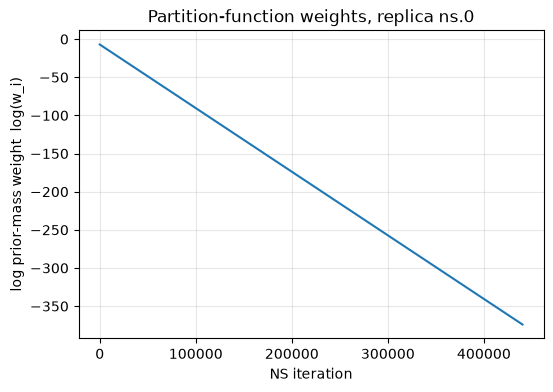

In [5]:
_iters0, _H0, _V0, _n_walkers0, _n_cull0, _n_atoms0 = read_ns_energies(
    input_dir / f"{FILE_PREFIX}.{replica_indices[0]}.energies"
)
log_w_dead0 = calc_log_weights(len(_H0), _n_walkers0, _n_cull0)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(_iters0, log_w_dead0)
ax.set_xlabel("NS iteration")
ax.set_ylabel("log prior-mass weight  log(w_i)")
ax.set_title(f"Partition-function weights, replica {FILE_PREFIX}.{replica_indices[0]}")
ax.grid(alpha=0.3)
plt.show()

## `<H>(T)` for every replica

For each replica we wrap its dead-point history in a `jaxrens.postprocess.monitor.Monitor`
and call `Monitor.expectation(observable, T)`, which internally builds the same weights as
above and evaluates `sum_i w_i(T) * observable_i / sum_i w_i(T)`. Passing `mon.dead_energies`
as the observable gives `<H>(T)` directly.

**Live-population caveat**: these are completed, pre-existing runs without a separate
"final live walkers" file, so `Monitor` (which expects one) is given the last `n_walkers`
dead points as a stand-in live population. After `n_dead ~ 4*10^5` iterations with
`n_walkers = 1200` the remaining prior-mass shrinks to `exp(n_dead * log_t) ~ 10^-160`
(see the weight plot above), so the live-shell contribution to any of the sums below is
numerically negligible regardless of which points are used to stand in for it.

In [6]:
monitors: dict[int, Monitor] = {}
H_of_T: dict[int, np.ndarray] = {}

for idx, pressure_gpa in zip(replica_indices, pressures_gpa):
    iterations, enthalpies, volumes, n_walkers, n_cull, n_atoms = read_ns_energies(
        input_dir / f"{FILE_PREFIX}.{idx}.energies"
    )
    mon = Monitor(
        dead_energies=enthalpies,
        dead_volumes=volumes,
        live_energies=enthalpies[-n_walkers:],
        live_volumes=volumes[-n_walkers:],
        log_evidence=float("nan"),
        iteration=len(enthalpies),
        n_live=n_walkers,
        n_cull=n_cull,
        energy_trace=enthalpies,
        iteration_trace=iterations,
        label=f"{FILE_PREFIX}.{idx} (P={pressure_gpa:g} GPa)",
    )
    monitors[idx] = mon
    H_of_T[idx] = mon.expectation(mon.dead_energies, T_grid, k_B=K_BOLTZMANN)
    print(f"replica {idx:2d}  P={pressure_gpa:5.1f} GPa  n_dead={mon.n_dead}")

replica  0  P=  1.0 GPa  n_dead=440170


replica  1  P=  2.0 GPa  n_dead=440170


replica  2  P=  3.0 GPa  n_dead=440170


replica  3  P=  4.0 GPa  n_dead=440170


replica  4  P=  5.0 GPa  n_dead=440170


...

replica 11  P= 12.0 GPa  n_dead=440170


replica 12  P= 13.0 GPa  n_dead=440170


replica 13  P= 14.0 GPa  n_dead=440170


replica 14  P= 15.0 GPa  n_dead=440170


replica 15  P= 16.0 GPa  n_dead=440170


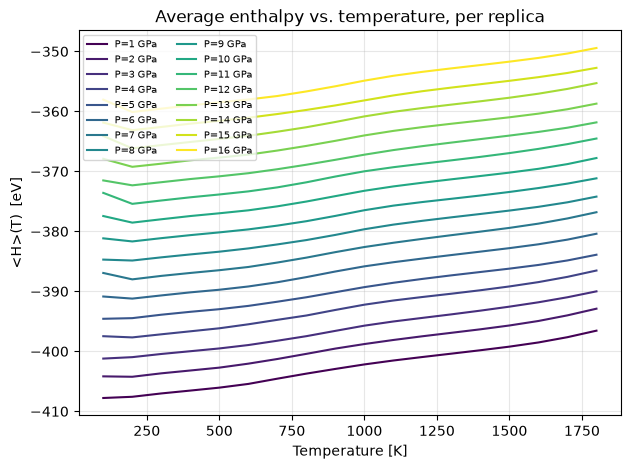

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
cmap = plt.get_cmap("viridis")
for i, idx in enumerate(replica_indices):
    color = cmap(i / max(len(replica_indices) - 1, 1))
    ax.plot(T_grid, H_of_T[idx], color=color, label=f"P={pressures_gpa[i]:g} GPa")
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("<H>(T)  [eV]")
ax.set_title("Average enthalpy vs. temperature, per replica")
ax.legend(fontsize=7, ncol=2)
ax.grid(alpha=0.3)
plt.show()

## Pick the closest structure for every (replica, temperature)

**Cached**: this is the expensive step (reading all 16 full ~44k-frame trajectories) --
if `griglia.extxyz` already exists at `output_path` it's loaded back directly and the
trajectories are never reopened. Delete that file (or change `OUTPUT_PATH`/the
temperature grid/replica selection above) to force it to be rebuilt from scratch.

In [8]:
if output_path.exists():
    grid_atoms = ase.io.read(output_path, index=":")
    print(f"Loaded {len(grid_atoms)} cached grid structures from {output_path}")
else:
    grid_atoms = []

    for idx, pressure_gpa in zip(replica_indices, pressures_gpa):
        iterations, enthalpies, _volumes, *_ = read_ns_energies(
            input_dir / f"{FILE_PREFIX}.{idx}.energies"
        )
        traj_path = input_dir / f"{FILE_PREFIX}.{idx}.traj.extxyz"
        traj_atoms = ase.io.read(traj_path, index=":")
        traj_iters = np.array([at.info["iter"] for at in traj_atoms])

        for T, e_target in zip(T_grid, H_of_T[idx]):
            dead_idx = int(np.argmin(np.abs(enthalpies - e_target)))
            iter_target = iterations[dead_idx]

            frame_idx = int(np.argmin(np.abs(traj_iters - iter_target)))
            atom = traj_atoms[frame_idx].copy()
            atom.info["Temperature"] = float(T)
            atom.info["Pressure"] = float(pressure_gpa)
            atom.info["Pressure_units"] = "GPa"
            atom.info["Pressure_eVA3"] = float(pressure_gpa) * GPA_TO_EVA3
            atom.info["replica"] = idx
            atom.info["source_ns_iteration"] = int(iter_target)
            atom.info["matched_traj_iteration"] = int(traj_iters[frame_idx])
            grid_atoms.append(atom)

        del traj_atoms, traj_iters
        print(f"replica {idx:2d}  P={pressure_gpa:5.1f} GPa  -> {len(T_grid)} structures picked")

    print(f"\ntotal structures in grid: {len(grid_atoms)}")

Loaded 288 cached grid structures from /home/seraftu/Work/code/dim_red/experiments/test_strucutres/ti_trajs/griglia.extxyz


## Write the grid

In [9]:
ase.io.write(output_path, grid_atoms)
print(f"wrote {len(grid_atoms)} structures to {output_path}")

wrote 288 structures to /home/seraftu/Work/code/dim_red/experiments/test_strucutres/ti_trajs/griglia.extxyz


## Sanity check

Scatter of the (Temperature, Pressure) grid actually written, and how far each picked
trajectory frame's `iter` tag ended up from the NS iteration it was aiming for (bounded
by `traj_interval`, since frames are only saved every `traj_interval` iterations).

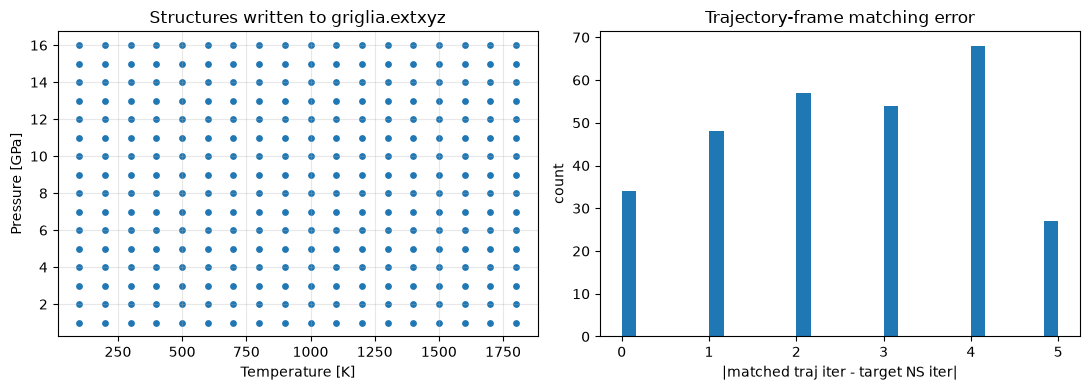

In [10]:
temps = [a.info["Temperature"] for a in grid_atoms]
press = [a.info["Pressure"] for a in grid_atoms]
iter_gap = [
    abs(a.info["matched_traj_iteration"] - a.info["source_ns_iteration"])
    for a in grid_atoms
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.scatter(temps, press, s=15)
ax1.set_xlabel("Temperature [K]")
ax1.set_ylabel("Pressure [GPa]")
ax1.set_title("Structures written to griglia.extxyz")
ax1.grid(alpha=0.3)

ax2.hist(iter_gap, bins=30)
ax2.set_xlabel("|matched traj iter - target NS iter|")
ax2.set_ylabel("count")
ax2.set_title("Trajectory-frame matching error")
plt.tight_layout()
plt.show()

## Classify the grid with the round 15/16 best model, and visualize

Uses the already-trained round 15 "best combo" SupCon body
(`configs/single_run_supcon_best_combo.example.yaml`: encoder `[256, 128]`, `latent_dim: 32`)
together with its round 15 `hierarchical_supcon` tail
(`configs/tail_train_hierarchical_supcon_best_combo.example.yaml`: stage 1 predicts crystal
family, stage 2 routes each structure to its *predicted* family's own SupCon spacegroup
expert -- a separate small SupCon body+classifier trained on that family's native SOAP
subset) to predict family then spacegroup for every structure in the NS grid. For the
per-family spacegroup visualizations we use round 16's per-family-tuned visualizer
architecture (`experiments/round16_sg_viz_tuning_notes.md`) instead of the uniform
`[64, 32]` baseline the `hierarchical_supcon_best_combo` tail itself was saved with, since
those tuned weights give a visibly better 2D separation for 5 of the 6 non-Cubic families.

This does **not** use `dim_red.pipeline.inference.predict_hierarchical` -- that helper only
supports the plain `hierarchical` tail kind (a `ClassificationTail` expert per family, on
top of the *same* frozen body), whereas `hierarchical_supcon`'s stage-2 experts are each
their own independently-trained SupCon body operating on raw standardized SOAP features.
The prediction logic below mirrors `predict_hierarchical`'s structure for this different
architecture instead.

In [11]:
DIMRED_RUN_DIR = Path(
    "/home/seraftu/Work/code/dim_red/experiments/runs/experiment_pipeline_best_combo/"
    "model-supcon_hd-256-128_pyxtal-cub-hex-mon-ort-tet-tri-tri_nsp1_supcon-family_only_tau0.05_lf1"
)
HIERARCHICAL_SUBDIR = "hierarchical_supcon_best_combo"
FAMILY_VIZ_SUBDIR = "visualization_family_only_euclidean"
SG_VIZ_TUNE_DIR = Path(
    "/home/seraftu/Work/code/dim_red/experiments/runs/experiment_viz_tune_orthorhombic_tetragonal"
)

# Round 16's winning per-family SG-visualizer hidden_dim (see src/dim_red/pipeline/CLAUDE.md
# and experiments/round16_sg_viz_tuning_notes.md). Cubic was deliberately never tuned there
# (rounds 13-15 found it structurally insensitive to tail capacity) -- it keeps best_combo's
# own baseline [64, 32] visualizer, loaded straight from HIERARCHICAL_SUBDIR below.
SG_VIZ_WINNER_TAG = {
    "Hexagonal": "64_32_16",
    "Monoclinic": "64_32_16",
    "Orthorhombic": "64_32_16",
    "Tetragonal": "128_64",
    "Triclinic": "64_32_16",
    "Trigonal": "64_32_16",
}
CANDIDATE_HIDDEN_DIMS = {  # tag -> hidden_dim, mirrors examples/tune_sg_visualization_hidden_dims.py
    "64_32": [64, 32],
    "128_64": [128, 64],
    "64_32_16": [64, 32, 16],
    "128_64_32": [128, 64, 32],
}

In [12]:
import yaml as _yaml
import jax
from flax import serialization

from dim_red.pipeline.inference import load_trained_run, encode_structures
from dim_red.soap import compute_soap
from dim_red.utils import apply_standardization
from dim_red.supcon.model import SupConEncoder
from dim_red.supcon.tails import ClassificationTail, VisualizationTail

/home/seraftu/miniconda3/envs/dmred/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Classify the grid (cached -- skips model loading, SOAP and inference
entirely once already run once)

Stage 1 (family) then stage 2 (spacegroup, routed by the *predicted* family to that
family's own SupCon SG expert -- a separate small SupCon body trained on that family's
native SOAP subset, not on the main body's embedding). **Cached**: if
`griglia_classified.extxyz` and its companion embeddings cache already exist, both
stages are skipped entirely and their results (`family_pred`/`spacegroup_pred`/`r_main`/
`r_sg_all`, the latter two needed by the visualization cells below) are loaded straight
from disk -- no model loading, no SOAP computation, no forward pass. Delete
`griglia_classified.extxyz`/`griglia_embeddings_cache.npz` (or change `DIMRED_RUN_DIR`/
`HIERARCHICAL_SUBDIR` above) to force reclassification.

This does **not** use `dim_red.pipeline.inference.predict_hierarchical` -- that helper
only supports the plain `hierarchical` tail kind (a `ClassificationTail` expert per
family, on top of the *same* frozen body), whereas `hierarchical_supcon`'s stage-2
experts are each their own independently-trained SupCon body operating on raw
standardized SOAP features. The prediction logic below mirrors
`predict_hierarchical`'s structure for this different architecture instead.

In [13]:
classified_path = input_dir / "griglia_classified.extxyz"
embeddings_cache_path = input_dir / "griglia_embeddings_cache.npz"

# Cheap regardless of the cache below -- both branches, and the per-family SG
# visualization cell further down, need hs_config/sg_experts_dir.
hier_dir = DIMRED_RUN_DIR / "tails" / HIERARCHICAL_SUBDIR
with open(hier_dir / "tail_config.yaml") as f:
    hs_config = _yaml.safe_load(f)["hierarchical_supcon"]
sg_experts_dir = hier_dir / "sg_experts"

if classified_path.exists() and embeddings_cache_path.exists():
    grid_atoms = ase.io.read(classified_path, index=":")
    family_pred = [a.info["predicted_family"] for a in grid_atoms]
    spacegroup_pred = np.array(
        [a.info["predicted_spacegroup"] for a in grid_atoms], dtype=np.int64
    )
    with np.load(embeddings_cache_path) as npz:
        r_main = npz["r_main"]
        r_sg_all = npz["r_sg_all"]
    print(f"Loaded cached classification for {len(grid_atoms)} structures from {classified_path}")
else:
    loaded_run = load_trained_run(DIMRED_RUN_DIR)
    r_main = encode_structures(loaded_run, grid_atoms)  # (n_grid, 32) -- main body's own latent space

    with np.load(hier_dir / "tail_predictions.npz", allow_pickle=True) as npz:
        family_classes = [str(c) for c in npz["family_classes"].tolist()]

    family_tail = ClassificationTail(
        input_dim=r_main.shape[1],
        hidden_dim=hs_config["head_hidden_dim"],
        n_family_classes=len(family_classes),
    )
    with open(hier_dir / "family" / "tail_params.msgpack", "rb") as f:
        family_tail.params = serialization.from_bytes(family_tail.params, f.read())

    family_probs = np.asarray(jax.nn.softmax(family_tail.classify_family(r_main), axis=-1))
    family_pred = [family_classes[i] for i in family_probs.argmax(axis=1)]
    for fam in sorted(set(family_pred)):
        print(f"{fam:12s}: {family_pred.count(fam)} structures")

    def _soap_matrix(atoms_list, loaded):
        kwargs = dict(loaded.config.soap.as_kwargs())
        kwargs["species"] = loaded.species
        kwargs["average"] = "outer"
        vectors = compute_soap(atoms_list, **kwargs)
        return np.asarray(vectors).reshape(len(atoms_list), -1)

    X_grid_raw = _soap_matrix(grid_atoms, loaded_run)
    X_grid_std = apply_standardization(X_grid_raw, loaded_run.feature_mean, loaded_run.feature_std)

    spacegroup_pred = np.zeros(len(grid_atoms), dtype=np.int64)
    r_sg_all = np.zeros((len(grid_atoms), hs_config["sg_latent_dim"]), dtype=np.float32)

    for family in sorted(set(family_pred)):
        rows = [i for i, f in enumerate(family_pred) if f == family]
        expert_dir = sg_experts_dir / family
        with open(expert_dir / "local_spacegroup_classes.yaml") as f:
            local_classes = _yaml.safe_load(f)["local_spacegroup_classes"]

        sg_body = SupConEncoder(
            input_dim=X_grid_std.shape[1],
            encoder_hidden_dim=hs_config["sg_encoder_hidden_dim"],
            latent_dim=hs_config["sg_latent_dim"],
        )
        with open(expert_dir / "sg_body_params.msgpack", "rb") as f:
            sg_body.params = serialization.from_bytes(sg_body.params, f.read())
        r_sg = np.asarray(sg_body.encode(X_grid_std[rows]))
        r_sg_all[rows] = r_sg

        sg_classifier = ClassificationTail(
            input_dim=hs_config["sg_latent_dim"],
            hidden_dim=hs_config["sg_classifier_hidden_dim"],
            n_family_classes=len(local_classes),
        )
        with open(expert_dir / "classifier_tail_params.msgpack", "rb") as f:
            sg_classifier.params = serialization.from_bytes(sg_classifier.params, f.read())

        local_probs = np.asarray(jax.nn.softmax(sg_classifier.classify_family(r_sg), axis=-1))
        local_pred_ids = local_probs.argmax(axis=1)
        for row_pos, i in enumerate(rows):
            spacegroup_pred[i] = local_classes[local_pred_ids[row_pos]]
        print(f"{family:12s}: routed to {len(local_classes)}-spacegroup expert, {len(rows)} structures")

    for atom, fam, sg in zip(grid_atoms, family_pred, spacegroup_pred):
        atom.info["predicted_family"] = fam
        atom.info["predicted_spacegroup"] = int(sg)

    ase.io.write(classified_path, grid_atoms)
    np.savez(embeddings_cache_path, r_main=r_main, r_sg_all=r_sg_all)
    print(f"\nwrote {len(grid_atoms)} classified structures to {classified_path}")

Loaded cached classification for 288 structures from /home/seraftu/Work/code/dim_red/experiments/test_strucutres/ti_trajs/griglia_classified.extxyz


### Family-level visualization tail: training data (background) vs. the grid (overlay)

Uses the round 15 `visualization_family_only_euclidean` tail (global, family-level 2D
projection of the main body's 32-d embedding). Background points: `alpha=0.5`, white
edges, colored by family (`tab10`), same style `dim_red.analysis.plotting.plot_reduced_space`
uses. Overlay (grid) points: the *same* marker and size as the background, just opaque
(no alpha) with a black edge instead of white, colored to match whichever family label
they share with the background -- not `dim_red.analysis.plotting.plot_applied_structures`'
own star-marker overlay style, so this is a small local function instead of a reused one.

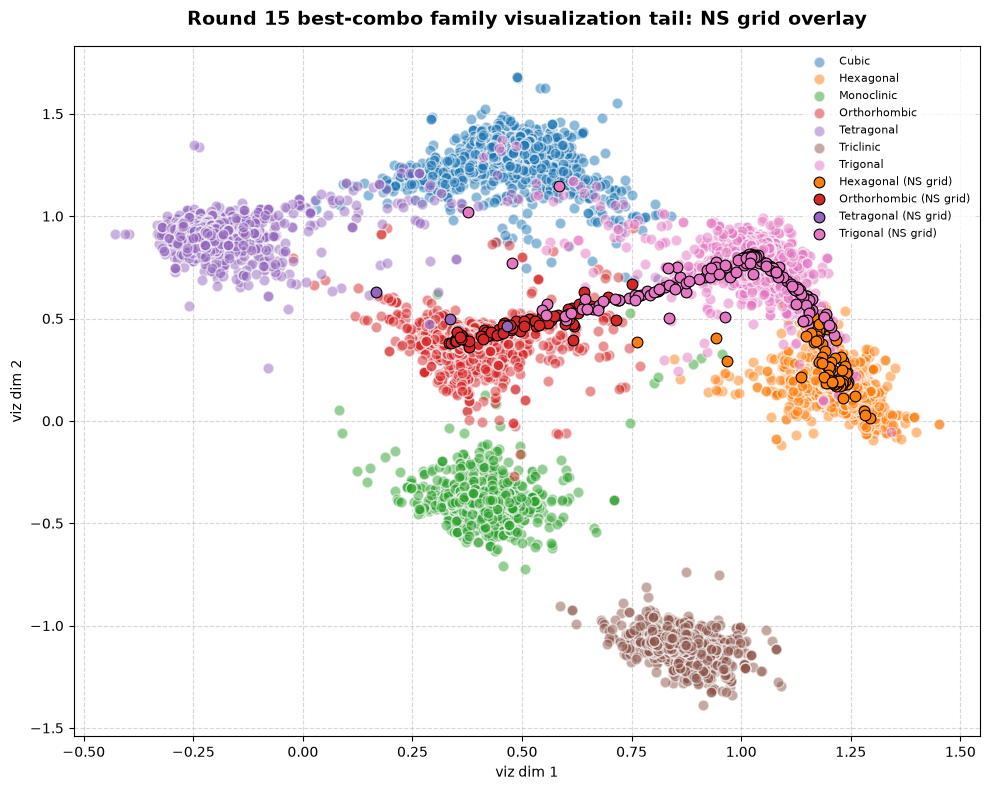

In [14]:
def plot_family_applied(train_z, train_labels, new_z, new_labels, title, save_path):
    unique_labels = sorted(set(train_labels) | set(new_labels))
    cmap = plt.get_cmap("tab10")
    color_for = {label: cmap(i % 10) for i, label in enumerate(unique_labels)}

    fig, ax = plt.subplots(figsize=(10, 8))
    for label in sorted(set(train_labels)):
        mask = [lbl == label for lbl in train_labels]
        coords = train_z[mask]
        ax.scatter(
            coords[:, 0], coords[:, 1], label=label, color=color_for[label],
            alpha=0.5, edgecolors="w", s=60, zorder=2,
        )
    for label in sorted(set(new_labels)):
        mask = [lbl == label for lbl in new_labels]
        coords = new_z[mask]
        ax.scatter(
            coords[:, 0], coords[:, 1], label=f"{label} (NS grid)", color=color_for[label],
            s=60, edgecolors="black", linewidths=0.8, zorder=3,
        )
    ax.set_xlabel("viz dim 1")
    ax.set_ylabel("viz dim 2")
    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)
    fig.tight_layout()
    fig.savefig(save_path, dpi=300)
    plt.show()
    return color_for


family_viz_dir = DIMRED_RUN_DIR / "tails" / FAMILY_VIZ_SUBDIR
with open(family_viz_dir / "tail_config.yaml") as f:
    viz_config = _yaml.safe_load(f)["visualization"]

family_viz_tail = VisualizationTail(
    input_dim=r_main.shape[1],
    hidden_dim=viz_config["hidden_dim"],
    output_dim=viz_config["viz_dim"],
)
with open(family_viz_dir / "tail_params.msgpack", "rb") as f:
    family_viz_tail.params = serialization.from_bytes(family_viz_tail.params, f.read())

z_grid_family = np.asarray(family_viz_tail.project(r_main))

with np.load(family_viz_dir / "tail_embeddings.npz", allow_pickle=True) as npz:
    train_family_z = npz["embeddings"]
    train_family_labels = npz["labels"].tolist()

family_color_for = plot_family_applied(
    train_family_z,
    train_family_labels,
    z_grid_family,
    family_pred,
    title="Round 15 best-combo family visualization tail: NS grid overlay",
    save_path=str(input_dir / "griglia_family_viz.png"),
)

### Per-family spacegroup visualization (round 16 winners), background vs. grid overlay

Round 16's palette fix (`experiments/round16_sg_viz_tuning_notes.md`): a continuous
`gist_ncar` colormap sampled once per distinct spacegroup *present in that family*
(59-68 classes make `tab10`/a legend both misleading and unreadable), no legend on the
background points, white edges + `alpha=0.8` for the background, reused here with the grid's
overlay points drawn the same way `plot_applied_structures` draws its own overlay (opaque,
black-edged stars) -- there's no existing helper combining that palette with an overlay, so
this one cell is new code rather than a reused plotting function.

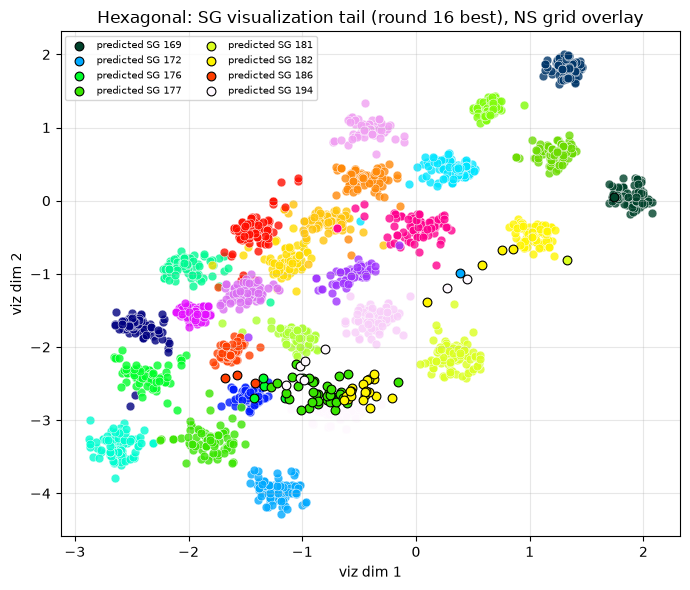

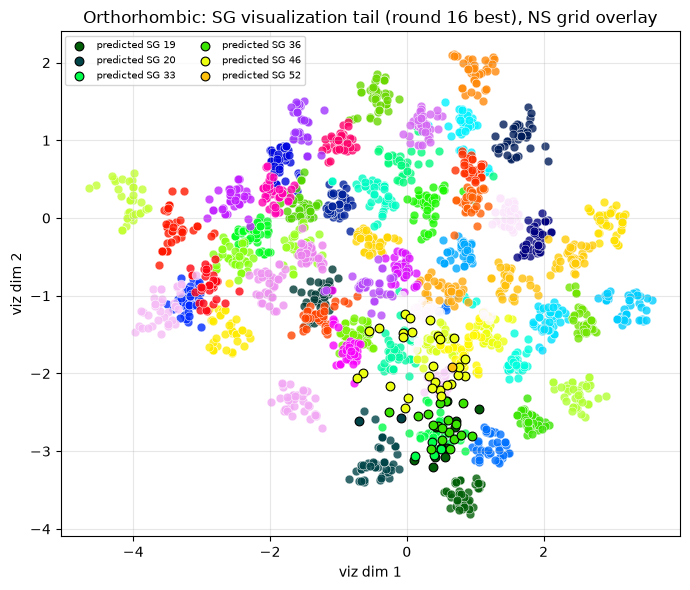

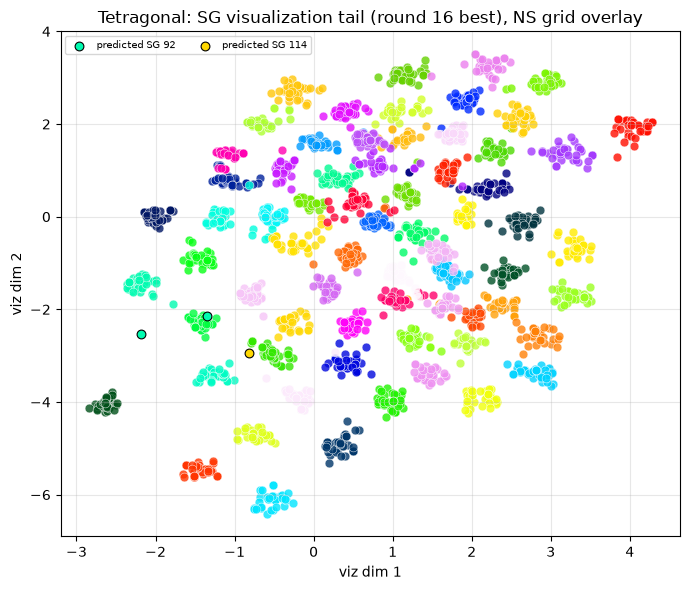

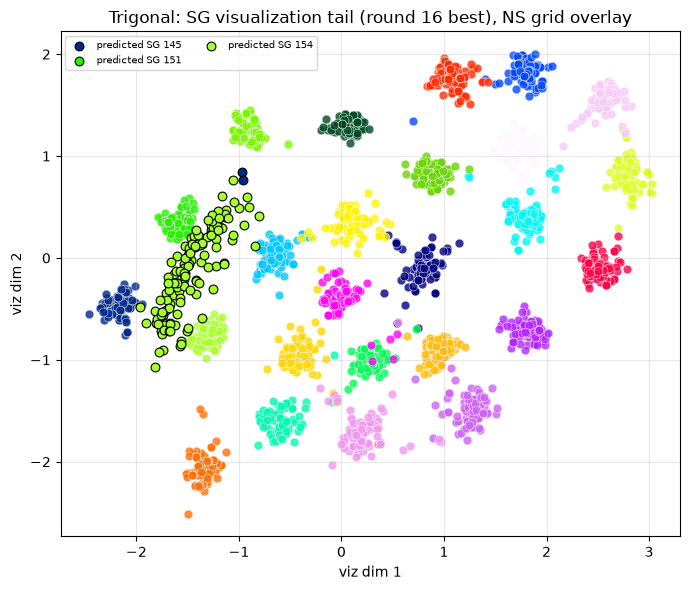

In [15]:
def load_sg_viz_tail(family):
    if family in SG_VIZ_WINNER_TAG:
        tag = SG_VIZ_WINNER_TAG[family]
        hidden_dim = CANDIDATE_HIDDEN_DIMS[tag]
        params_path = SG_VIZ_TUNE_DIR / family / tag / "visualization_tail_params.msgpack"
        bg_npz_path = SG_VIZ_TUNE_DIR / family / tag / "visualization_embeddings.npz"
    else:
        hidden_dim = hs_config["sg_visualization_hidden_dim"]
        params_path = sg_experts_dir / family / "visualization_tail_params.msgpack"
        bg_npz_path = sg_experts_dir / family / "visualization_embeddings.npz"

    tail = VisualizationTail(input_dim=hs_config["sg_latent_dim"], hidden_dim=hidden_dim, output_dim=2)
    with open(params_path, "rb") as f:
        tail.params = serialization.from_bytes(tail.params, f.read())
    with np.load(bg_npz_path, allow_pickle=True) as npz:
        bg_z = npz["embeddings"]
        bg_sg = np.asarray(npz["spacegroups"]).astype(np.int64)
    return tail, bg_z, bg_sg


def plot_sg_family_applied(family, bg_z, bg_sg, new_z, new_sg, save_path):
    all_sg = sorted(set(bg_sg.tolist()) | set(int(s) for s in new_sg))
    cmap = plt.get_cmap("gist_ncar")
    color_for = {sg: cmap(i / max(len(all_sg) - 1, 1)) for i, sg in enumerate(all_sg)}

    fig, ax = plt.subplots(figsize=(7, 6))
    for sg in sorted(set(bg_sg.tolist())):
        mask = bg_sg == sg
        ax.scatter(
            bg_z[mask, 0], bg_z[mask, 1], color=color_for[sg], alpha=0.8,
            edgecolors="white", linewidths=0.4, s=40,
        )
    for sg in sorted(set(int(s) for s in new_sg)):
        mask = np.array([int(s) == sg for s in new_sg])
        ax.scatter(
            new_z[mask, 0], new_z[mask, 1], color=color_for[sg], s=40,
            edgecolors="black", linewidths=0.8, zorder=3, label=f"predicted SG {sg}",
        )
    ax.set_title(f"{family}: SG visualization tail (round 16 best), NS grid overlay")
    ax.set_xlabel("viz dim 1")
    ax.set_ylabel("viz dim 2")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()


for family in sorted(set(family_pred)):
    rows = [i for i, f in enumerate(family_pred) if f == family]
    r_sg = r_sg_all[rows]
    viz_tail, bg_z, bg_sg = load_sg_viz_tail(family)
    z_new = np.asarray(viz_tail.project(r_sg))
    new_sg_local = spacegroup_pred[rows]
    plot_sg_family_applied(
        family, bg_z, bg_sg, z_new, new_sg_local,
        save_path=input_dir / f"griglia_sg_viz_{family.lower()}.png",
    )

### (T, P) grid, redone as its own plot, colored by predicted spacegroup or family

The sanity-check scatter earlier in this notebook only shows which (T, P) cells were
filled and how good the trajectory-frame match was; it says nothing about *what structure*
was picked. This redraws it standalone -- pressure on x, temperature on y -- once colored
by the classifier's predicted spacegroup (one consistent color per spacegroup number across
the whole grid, unlike the per-family plots above, which each use a palette local to that
family's own spacegroup vocabulary) and once colored by predicted family only.

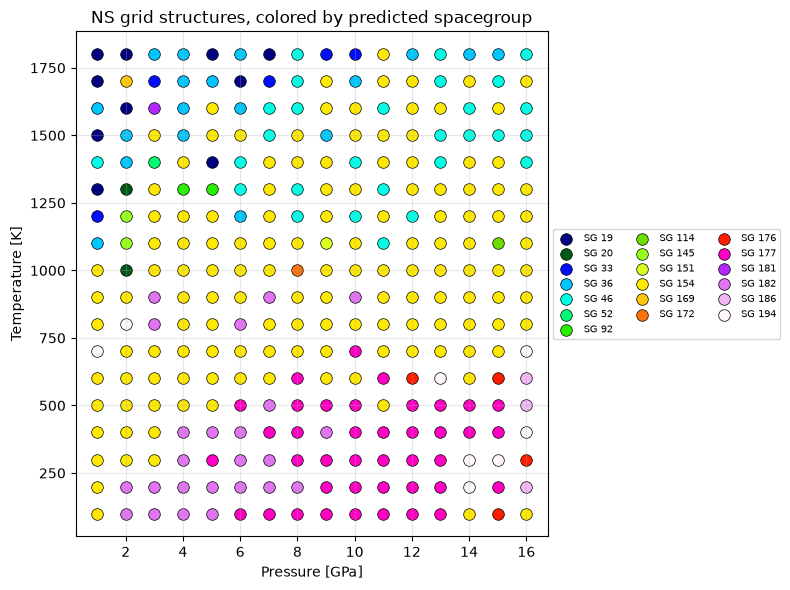

In [16]:
all_predicted_sg = sorted(set(int(s) for s in spacegroup_pred))
cmap_global = plt.get_cmap("gist_ncar")
global_color_for = {
    sg: cmap_global(i / max(len(all_predicted_sg) - 1, 1))
    for i, sg in enumerate(all_predicted_sg)
}

temps_arr = np.array(temps)
press_arr = np.array(press)

fig, ax = plt.subplots(figsize=(8, 6))
for sg in all_predicted_sg:
    mask = spacegroup_pred == sg
    ax.scatter(
        press_arr[mask], temps_arr[mask], color=global_color_for[sg], s=70,
        edgecolors="black", linewidths=0.5, label=f"SG {sg}",
    )
ax.set_xlabel("Pressure [GPa]")
ax.set_ylabel("Temperature [K]")
ax.set_title("NS grid structures, colored by predicted spacegroup")
ax.legend(fontsize=7, ncol=3, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(input_dir / "griglia_grid_by_spacegroup.png", dpi=200, bbox_inches="tight")
plt.show()

### Same grid, colored by predicted family only

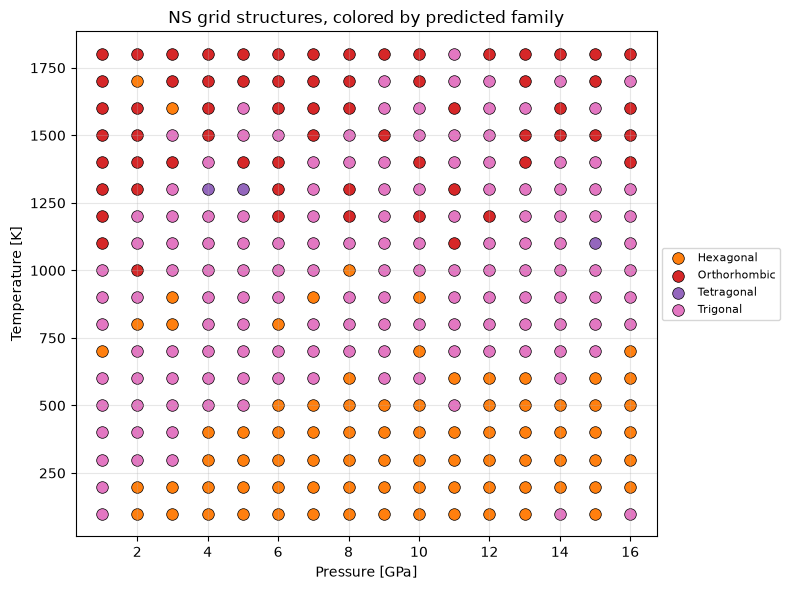

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for fam in sorted(set(family_pred)):
    mask = np.array([f == fam for f in family_pred])
    ax.scatter(
        press_arr[mask], temps_arr[mask], color=family_color_for[fam], s=70,
        edgecolors="black", linewidths=0.5, label=fam,
    )
ax.set_xlabel("Pressure [GPa]")
ax.set_ylabel("Temperature [K]")
ax.set_title("NS grid structures, colored by predicted family")
ax.legend(fontsize=8, ncol=1, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(input_dir / "griglia_grid_by_family.png", dpi=200, bbox_inches="tight")
plt.show()

## Thermal averages over every trajectory frame

Everything above picks **one** frame per (T, P) -- the one whose enthalpy is closest to
<H>(T). From here on every one of the ~44k frames per replica is used instead, each
weighted by its NS partition-function weight, so that the family is a proper thermal
average rather than a single representative:

$$
P_P(f\,|\,T) = \frac{\sum_i w_i\, e^{-H_i/k_BT}\;\mathbb{1}[f_i = f]}{\sum_i w_i\, e^{-H_i/k_BT}},
\qquad \log w_i = i\log t + \log(1-t),\;\; t = \tfrac{N-n_{cull}}{N+1-n_{cull}}
$$

The per-frame evaluations come from `examples/evaluate_ns_trajectories.py` (`dim_red` master,
run on datalab via `slurm/evaluate_ns_trajectories.sbatch`), one `ns.<i>.eval.npz` per replica
-- the same round 15 best-combo body + `hierarchical_supcon` tail used above, applied to every
frame (checked: it reproduces the 18/18 family and spacegroup predictions of
`griglia_classified.extxyz` on replica 0).

Conventions:
- **Each trajectory frame is a dead point**, matched exactly by `info["iter"]` (frames are
  saved every `traj_interval = 10` NS iterations). The sums above run over frames only; the
  missing factor 10 is a constant and cancels in the ratio. The weights are normalized over
  the frames themselves.
- **H comes from `.energies`** (`enthalpy`), i.e. the value NS actually ordered the walkers
  by. The frame's own `energy + P V` differs by ~0.015 eV (median) -- the traj energy looks
  re-evaluated (`evaluate_uncertainties_traj=T`) -- and by several eV in the very first
  iterations, where the thermal weight is negligible anyway.
- **Hard vs. soft labels**: *hard* uses the argmax family of each frame (a strict thermal
  fraction); *soft* averages the full softmax, which also carries the classifier's own
  uncertainty. Both are computed.
- **$C_p$** is the configurational heat capacity $\beta^2\,\mathrm{Var}(H)/N$ from *all* ~440k
  dead points (`Monitor.heat_capacity`), not just the saved frames. NS samples configurations
  only, so the kinetic $3/2\,k_B$ per atom is not included.

In [18]:
from scipy.special import logsumexp

# Output of examples/evaluate_ns_trajectories.py (copied back from datalab).
EVAL_DIR = Path("/home/seraftu/Work/code/dim_red/experiments/runs/ns_traj_eval/ti_trajs")

# Finer and wider than T_grid above: the melting peak of C_p sits near ~1900 K.
T_FINE = np.arange(50.0, 3000.0 + 1e-9, 10.0)

# Only the light per-frame arrays -- the SOAP vectors, positions, forces and
# SG-expert embeddings stay on disk until an analysis actually needs them.
EVAL_KEYS = (
    "iter", "enthalpy", "log_w", "family_logits", "family_pred_idx", "sg_pred",
    "soap_atom_msd_rel",
)

evals = {}
for idx in replica_indices:
    with np.load(EVAL_DIR / f"{FILE_PREFIX}.{idx}.eval.npz") as npz:
        evals[idx] = {k: npz[k] for k in EVAL_KEYS}
        family_classes = [str(f) for f in npz["family_classes"]]
        assert float(npz["pressure_gpa"]) == pressures_gpa[replica_indices.index(idx)]
    assert np.array_equal(evals[idx]["enthalpy"], monitors[idx].dead_energies[evals[idx]["iter"]])

FAMILY_COLORS = {f: plt.get_cmap("tab10")(i) for i, f in enumerate(sorted(family_classes))}
print(f"{len(evals)} replicas x {len(evals[replica_indices[0]]['iter'])} frames, families: {family_classes}")

16 replicas x 44017 frames, families: ['Cubic', 'Hexagonal', 'Monoclinic', 'Orthorhombic', 'Tetragonal', 'Triclinic', 'Trigonal']


### Frame weights and thermal averages

`frame_weights` returns the normalized weights $p_i(T)$ over the frames, shape
`(n_T, n_frames)`; every thermal average below is then a single matrix product. Also
tracked: the **effective sample size** $\mathrm{ESS}(T) = 1/\sum_i p_i(T)^2$ -- how many
frames actually carry each temperature's average -- and two classifier-independent/-dependent
order parameters:
- `soap_atom_msd_rel`: spread of the per-atom SOAP vectors around their structure mean
  (relative to its squared norm) -- small for a crystal, even a hot one, larger for a liquid;
- the entropy of the family softmax -- how unsure the classifier is.

In [19]:
def frame_weights(log_w, enthalpy, T, k_B=K_BOLTZMANN):
    log_p = log_w[None, :] - enthalpy[None, :] / (k_B * T[:, None])
    return np.exp(log_p - logsumexp(log_p, axis=1, keepdims=True))


thermo = {}
for idx in replica_indices:
    ev = evals[idx]
    p = frame_weights(ev["log_w"], ev["enthalpy"], T_FINE)
    probs = np.exp(ev["family_logits"] - logsumexp(ev["family_logits"], axis=1, keepdims=True))
    hard = np.eye(len(family_classes))[ev["family_pred_idx"]]
    thermo[idx] = dict(
        P_hard=p @ hard,
        P_soft=p @ probs,
        ess=1.0 / np.sum(p**2, axis=1),
        msd_rel=p @ ev["soap_atom_msd_rel"],
        entropy=p @ -(probs * np.log(probs + 1e-30)).sum(axis=1),
        cp_per_atom=monitors[idx].heat_capacity(T_FINE, k_B=K_BOLTZMANN) / n_atoms,
    )
    del p

np.savez(
    EVAL_DIR / "thermal_averages.npz",
    T=T_FINE,
    pressures_gpa=np.array(pressures_gpa),
    family_classes=np.array(family_classes),
    **{f"{key}__{idx}": val for idx, d in thermo.items() for key, val in d.items()},
)
print(f"saved {EVAL_DIR / 'thermal_averages.npz'}")

saved /home/seraftu/Work/code/dim_red/experiments/runs/ns_traj_eval/ti_trajs/thermal_averages.npz


### Heat capacity and effective sample size

Local maxima of $C_p$ (above a height threshold and above `CP_PEAK_T_MIN`, to skip the low-T noise below ~200 K) are kept in
`cp_peaks` and drawn as vertical guides in every plot below. Pressure is a magnitude, so it
gets a sequential colormap.

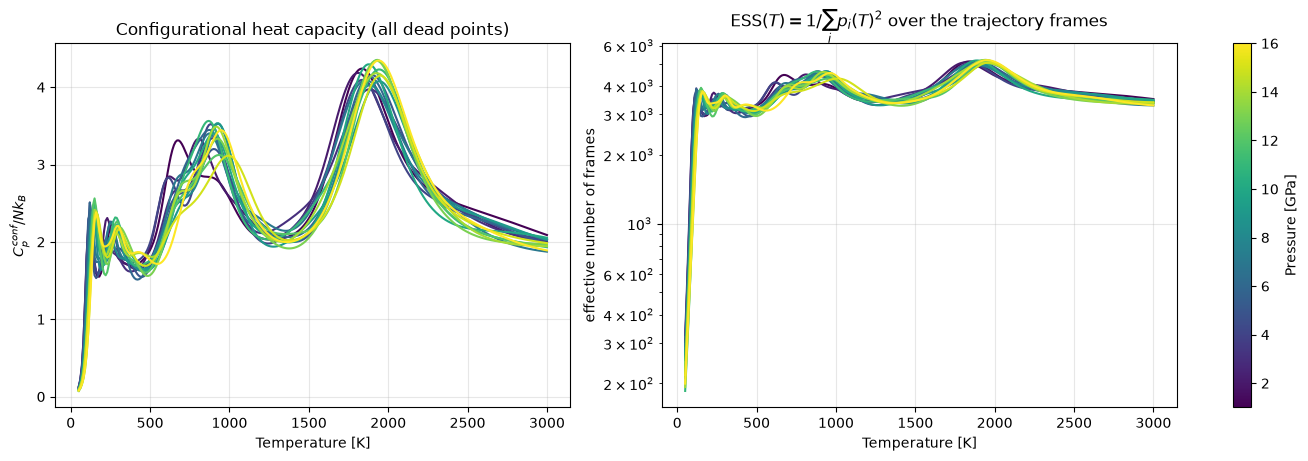

P=  1.0 GPa  C_p peaks at [680, 1830] K   min ESS=304
P=  2.0 GPa  C_p peaks at [620, 810, 1810] K   min ESS=254
P=  3.0 GPa  C_p peaks at [680, 890, 1880] K   min ESS=325
P=  4.0 GPa  C_p peaks at [610, 880, 1840] K   min ESS=264
P=  5.0 GPa  C_p peaks at [900, 1900] K   min ESS=292
P=  6.0 GPa  C_p peaks at [870, 1880] K   min ESS=252
P=  7.0 GPa  C_p peaks at [870, 1860] K   min ESS=215
P=  8.0 GPa  C_p peaks at [930, 1880] K   min ESS=272
P=  9.0 GPa  C_p peaks at [930, 1940] K   min ESS=254
P= 10.0 GPa  C_p peaks at [900, 1880] K   min ESS=226
P= 11.0 GPa  C_p peaks at [870, 1940] K   min ESS=185
P= 12.0 GPa  C_p peaks at [930, 1930] K   min ESS=238
P= 13.0 GPa  C_p peaks at [930, 1930] K   min ESS=211
P= 14.0 GPa  C_p peaks at [920, 1930] K   min ESS=193
P= 15.0 GPa  C_p peaks at [990, 1950] K   min ESS=217
P= 16.0 GPa  C_p peaks at [950, 1940] K   min ESS=200


In [20]:
def find_peaks_simple(y, x, min_height, x_min):
    i = np.where((y[1:-1] > y[:-2]) & (y[1:-1] > y[2:]) & (y[1:-1] > min_height))[0] + 1
    return x[i][x[i] >= x_min]


CP_PEAK_MIN = 2.5  # per atom, in k_B
CP_PEAK_T_MIN = 300.0  # K
cp_peaks = {
    idx: find_peaks_simple(thermo[idx]["cp_per_atom"], T_FINE, CP_PEAK_MIN, CP_PEAK_T_MIN)
    for idx in replica_indices
}
p_cmap = plt.get_cmap("viridis")
p_color = {idx: p_cmap(i / max(len(replica_indices) - 1, 1)) for i, idx in enumerate(replica_indices)}
p_norm = plt.Normalize(min(pressures_gpa), max(pressures_gpa))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
for idx, P in zip(replica_indices, pressures_gpa):
    ax1.plot(T_FINE, thermo[idx]["cp_per_atom"], color=p_color[idx], lw=1.5)
    ax2.plot(T_FINE, thermo[idx]["ess"], color=p_color[idx], lw=1.5)
ax1.set_ylabel(r"$C_p^{conf} / N k_B$")
ax1.set_title("Configurational heat capacity (all dead points)")
ax2.set_ylabel("effective number of frames")
ax2.set_yscale("log")
ax2.set_title(r"ESS$(T) = 1/\sum_i p_i(T)^2$ over the trajectory frames")
for ax in (ax1, ax2):
    ax.set_xlabel("Temperature [K]")
    ax.grid(alpha=0.3)
fig.colorbar(plt.cm.ScalarMappable(norm=p_norm, cmap=p_cmap), ax=[ax1, ax2], label="Pressure [GPa]")
plt.show()

for idx, P in zip(replica_indices, pressures_gpa):
    print(f"P={P:5.1f} GPa  C_p peaks at {cp_peaks[idx].astype(int).tolist()} K   min ESS={thermo[idx]['ess'].min():.0f}")

### $P(\mathrm{family}\,|\,T)$, one panel per pressure

Stacked thermal fractions (`LABEL_MODE = "hard"` or `"soft"`), with the $C_p$ peaks of that
replica as dashed vertical lines. Families that never exceed 1% at any T are left out of the
legend.

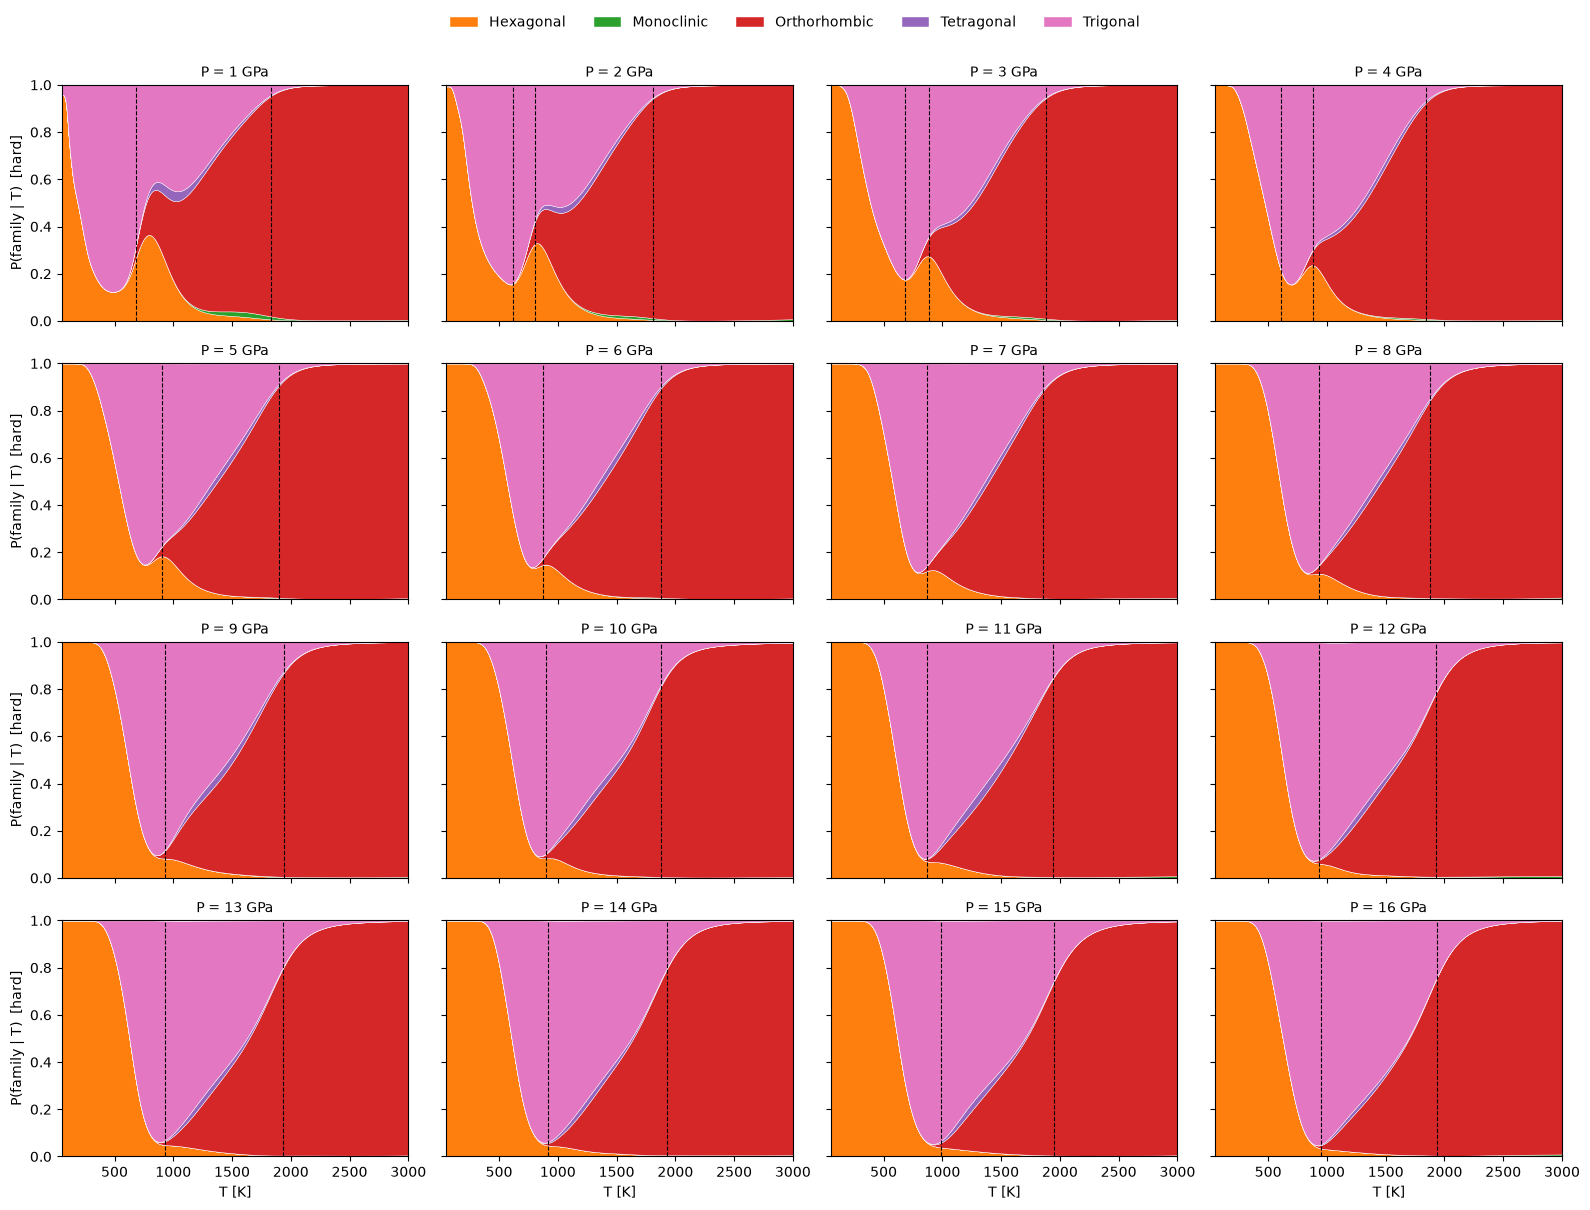

In [21]:
LABEL_MODE = "hard"  # or "soft"
key = f"P_{LABEL_MODE}"

shown = [
    f for fi, f in enumerate(family_classes)
    if max(thermo[idx][key][:, fi].max() for idx in replica_indices) > 0.01
]
n_cols = 4
n_rows = int(np.ceil(len(replica_indices) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
for ax, idx, P in zip(axes.flat, replica_indices, pressures_gpa):
    fractions = [thermo[idx][key][:, family_classes.index(f)] for f in shown]
    ax.stackplot(
        T_FINE, fractions, colors=[FAMILY_COLORS[f] for f in shown], labels=shown,
        edgecolor="white", linewidth=0.3,
    )
    for T_peak in cp_peaks[idx]:
        ax.axvline(T_peak, color="black", ls="--", lw=0.8)
    ax.set_title(f"P = {P:g} GPa", fontsize=10)
    ax.set_xlim(T_FINE[0], T_FINE[-1])
    ax.set_ylim(0, 1)
for ax in axes.flat[len(replica_indices):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("T [K]")
for ax in axes[:, 0]:
    ax.set_ylabel(f"P(family | T)  [{LABEL_MODE}]")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(shown), frameon=False, bbox_to_anchor=(0.5, 1.01))
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(EVAL_DIR / f"family_vs_T_{LABEL_MODE}.png", dpi=200, bbox_inches="tight")
plt.show()

### (P, T) map of the dominant family

Each (P, T) cell is colored by its most probable family, with the color's opacity set by
that probability (faded = mixed). Black markers: $C_p$ peaks of each replica. This is the
thermally averaged counterpart of the single-structure `griglia_grid_by_family.png` above.

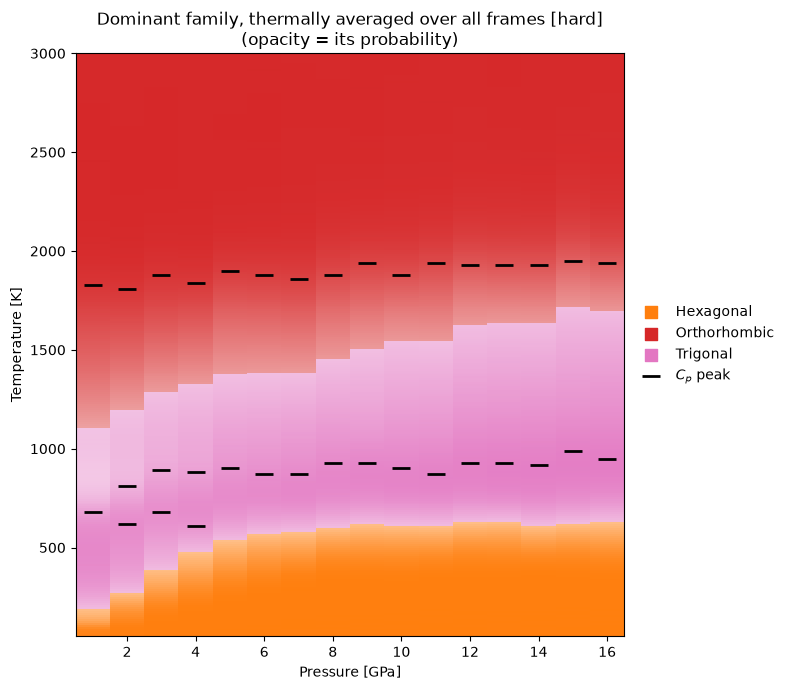

In [22]:
P_mat = np.stack([thermo[idx][key] for idx in replica_indices], axis=1)  # (n_T, n_P, n_fam)
dominant = P_mat.argmax(axis=-1)
confidence = P_mat.max(axis=-1)
rgba = np.array([[FAMILY_COLORS[family_classes[f]] for f in row] for row in dominant])
rgba[..., 3] = np.clip(confidence, 0.0, 1.0)

dP = np.diff(pressures_gpa).mean()
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(
    rgba, origin="lower", aspect="auto", interpolation="nearest",
    extent=(pressures_gpa[0] - dP / 2, pressures_gpa[-1] + dP / 2, T_FINE[0], T_FINE[-1]),
)
for idx, P in zip(replica_indices, pressures_gpa):
    ax.scatter([P] * len(cp_peaks[idx]), cp_peaks[idx], color="black", marker="_", s=150, lw=2)
present = sorted({family_classes[f] for f in np.unique(dominant)})
for f in present:
    ax.scatter([], [], color=FAMILY_COLORS[f], marker="s", s=80, label=f)
ax.scatter([], [], color="black", marker="_", s=150, lw=2, label=r"$C_p$ peak")
ax.set_xlabel("Pressure [GPa]")
ax.set_ylabel("Temperature [K]")
ax.set_title(f"Dominant family, thermally averaged over all frames [{LABEL_MODE}]\n(opacity = its probability)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
fig.tight_layout()
fig.savefig(EVAL_DIR / f"phase_map_family_{LABEL_MODE}.png", dpi=200, bbox_inches="tight")
plt.show()

### Order parameters: is the high-T state liquid?

The classifier has no "liquid" class (see the discussion of pyxtal's P1 structures): above
melting it still has to answer *some* family. Two thermally averaged indicators, each on
its own axis: the per-atom SOAP spread (independent of the classifier) and the entropy of
the classifier's family softmax.

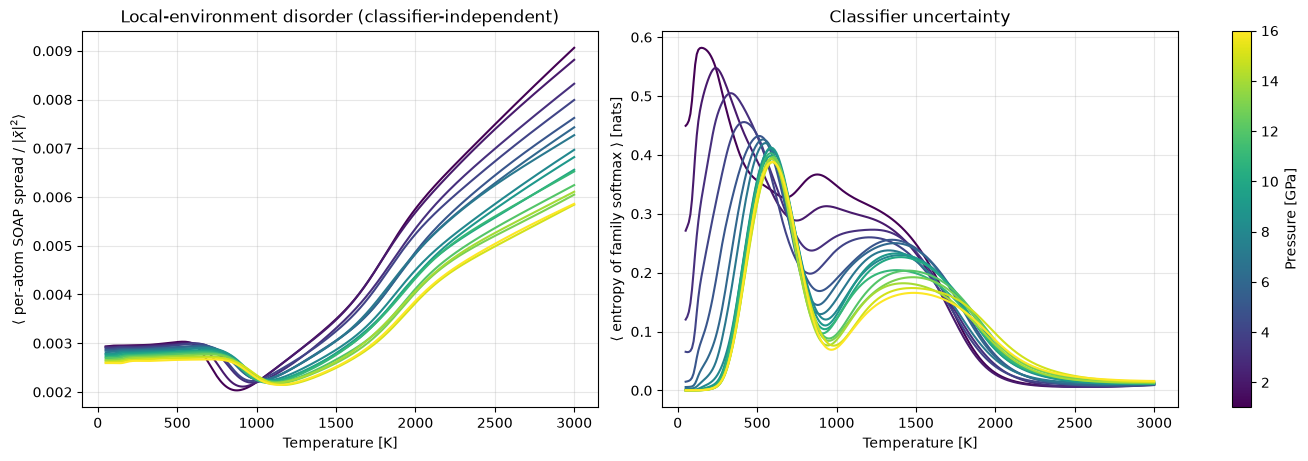

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
for idx in replica_indices:
    ax1.plot(T_FINE, thermo[idx]["msd_rel"], color=p_color[idx], lw=1.5)
    ax2.plot(T_FINE, thermo[idx]["entropy"], color=p_color[idx], lw=1.5)
ax1.set_ylabel(r"$\langle$ per-atom SOAP spread / $|\bar{x}|^2 \rangle$")
ax1.set_title("Local-environment disorder (classifier-independent)")
ax2.set_ylabel(r"$\langle$ entropy of family softmax $\rangle$ [nats]")
ax2.set_title("Classifier uncertainty")
for ax in (ax1, ax2):
    ax.set_xlabel("Temperature [K]")
    ax.grid(alpha=0.3)
fig.colorbar(plt.cm.ScalarMappable(norm=p_norm, cmap=p_cmap), ax=[ax1, ax2], label="Pressure [GPa]")
plt.show()

### First observations

- $C_p$ has two robust peaks at every pressure: one at ~1810-1950 K, rising slowly with P
  (the likely **melting** peak, where the per-atom SOAP spread also starts growing steadily),
  and one at ~610-990 K (a **solid-solid** transition; at 2-4 GPa it is split in two).
- Low T is **Hexagonal**, replaced by **Trigonal** at a crossover that moves up with P
  (~200 K at 1 GPa, ~600 K at 16 GPa). This crossover does *not* coincide with a $C_p$ peak,
  and the classifier is most uncertain right there (entropy peak ~0.4-0.6 nats), so it is
  probably the classifier drifting between neighboring labels of the same thermally
  distorted structure rather than a real phase change. Checking the predicted spacegroups
  on both sides is the next step.
- **Orthorhombic** takes over from the ~900 K $C_p$ peak onwards and stays dominant through and
  far beyond melting, with the classifier confident there (entropy -> 0). Below melting it
  could be a genuine high-T solid (bcc beta-Ti would be a natural candidate, and it can come
  out orthorhombic after thermal distortion); above melting it is necessarily the classifier's
  answer for a liquid, which it has no class for. So neither the family label nor the softmax
  entropy tells solid from liquid here -- the $C_p$ peak and the SOAP spread have to.

## Thermal averages per spacegroup

The same weighting as above, one level down the hierarchy: $P_P(\mathrm{SG}\,|\,T)$.

- **hard**: each frame counts once, for its hierarchical prediction `sg_pred` (argmax family,
  then that family's own SG expert's argmax).
- **soft**: each frame contributes its full marginal
  $P(\mathrm{SG}\,|\,x) = \sum_f P(f\,|\,x)\,P(\mathrm{SG}\,|\,f, x)$. This is possible because
  `evaluate_ns_trajectories.py` ran **every** family's SG expert on **every** frame, not just
  on the frames predicted to be in that family. The spacegroup vocabularies of different
  families are disjoint, so the sum just scatters each expert's softmax into the global list.

Summing the SG bands of one family gives back exactly that family's $P(f\,|\,T)$ from the
section above (hard: by construction; soft: because each expert's softmax sums to 1).

In [24]:
sg_by_family = {}
for idx in replica_indices:
    with np.load(EVAL_DIR / f"{FILE_PREFIX}.{idx}.eval.npz") as npz:
        evals[idx]["sg_logits"] = {f: npz[f"sg_logits__{f}"] for f in family_classes}
        for f in family_classes:
            sg_by_family[f] = [int(s) for s in npz[f"local_sg_classes__{f}"]]

all_sg = sorted(s for f in family_classes for s in sg_by_family[f])
family_of_sg = {s: f for f in family_classes for s in sg_by_family[f]}
sg_col = {s: i for i, s in enumerate(all_sg)}
assert len(sg_col) == sum(len(v) for v in sg_by_family.values()), "SG vocabularies overlap"

for idx in replica_indices:
    ev = evals[idx]
    p = frame_weights(ev["log_w"], ev["enthalpy"], T_FINE)
    hard = np.zeros((len(ev["iter"]), len(all_sg)))
    hard[np.arange(len(ev["iter"])), [sg_col[s] for s in ev["sg_pred"]]] = 1.0
    family_probs = np.exp(ev["family_logits"] - logsumexp(ev["family_logits"], axis=1, keepdims=True))
    soft = np.zeros_like(hard)
    for fi, f in enumerate(family_classes):
        logits = ev["sg_logits"][f]
        cond = np.exp(logits - logsumexp(logits, axis=1, keepdims=True))
        soft[:, [sg_col[s] for s in sg_by_family[f]]] = family_probs[:, fi : fi + 1] * cond
    thermo[idx]["P_sg_hard"] = p @ hard
    thermo[idx]["P_sg_soft"] = p @ soft
    # Consistency with the family section: each family's SG bands sum to its family band.
    for mode in ("hard", "soft"):
        fam_from_sg = np.stack(
            [thermo[idx][f"P_sg_{mode}"][:, [sg_col[s] for s in sg_by_family[f]]].sum(axis=1) for f in family_classes],
            axis=1,
        )
        assert np.allclose(fam_from_sg, thermo[idx][f"P_{mode}"], atol=1e-6)
    del p, hard, soft

np.savez(
    EVAL_DIR / "thermal_averages_sg.npz",
    T=T_FINE,
    pressures_gpa=np.array(pressures_gpa),
    spacegroups=np.array(all_sg),
    spacegroup_family=np.array([family_of_sg[s] for s in all_sg]),
    **{f"P_sg_{mode}__{idx}": thermo[idx][f"P_sg_{mode}"] for idx in replica_indices for mode in ("hard", "soft")},
)
print(f"{len(all_sg)} spacegroups in the vocabulary; saved {EVAL_DIR / 'thermal_averages_sg.npz'}")

230 spacegroups in the vocabulary; saved /home/seraftu/Work/code/dim_red/experiments/runs/ns_traj_eval/ti_trajs/thermal_averages_sg.npz


### Which spacegroups to show, and how to color them

Only SGs that reach `SG_MIN_PROB` at some (T, P) get their own band; the rest are folded
into a gray "Other". Color is a composite encoding: **hue = family** (the same `FAMILY_COLORS`
as above, so the plots can be compared directly), **shade + hatch = which SG inside that
family**. Bands are stacked grouped by family, so each family's block has the same outline
as in the family plot.

In [25]:
import matplotlib.colors as mcolors
from pymatgen.symmetry.groups import SpaceGroup

SG_MIN_PROB = 0.10
SG_KEY = f"P_sg_{LABEL_MODE}"
HATCHES = ["", "///", "...", "xxx", "\\\\\\", "ooo", "---"]

sg_max = np.max([thermo[idx][SG_KEY].max(axis=0) for idx in replica_indices], axis=0)
shown_sg = [
    s
    for f in family_classes
    for s in sorted(sg_by_family[f], key=lambda s: -sg_max[sg_col[s]])
    if sg_max[sg_col[s]] >= SG_MIN_PROB
]


def shade(color, k, n):
    # k-th of n shades of one hue: from 30% darker to 45% lighter than the family color.
    t = 0.0 if n == 1 else -0.30 + 0.75 * k / (n - 1)
    rgb = np.array(mcolors.to_rgb(color))
    return tuple(rgb + (1 - rgb) * t if t > 0 else rgb * (1 + t))


SG_STYLE = {}
for f in family_classes:
    members = [s for s in shown_sg if family_of_sg[s] == f]
    for k, s in enumerate(members):
        SG_STYLE[s] = dict(color=shade(FAMILY_COLORS[f], k, len(members)), hatch=HATCHES[k % len(HATCHES)])
OTHER_STYLE = dict(color=(0.8, 0.8, 0.8), hatch="")


def sg_label(s):
    return f"{s}  ${SpaceGroup.from_int_number(s).symbol}$  ({family_of_sg[s][:4]}.)"


for s in shown_sg:
    print(f"{sg_label(s):40s} max P = {sg_max[sg_col[s]]:.2f}")

186  $P6_3mc$  (Hexa.)                   max P = 1.00
182  $P6_322$  (Hexa.)                   max P = 1.00
177  $P622$  (Hexa.)                     max P = 1.00
194  $P6_3/mmc$  (Hexa.)                 max P = 0.16
176  $P6_3/m$  (Hexa.)                   max P = 0.14
19  $P2_12_12_1$  (Orth.)                max P = 0.85
33  $Pna2_1$  (Orth.)                    max P = 0.41
36  $Cmc2_1$  (Orth.)                    max P = 0.41
46  $Ima2$  (Orth.)                      max P = 0.32
20  $C222_1$  (Orth.)                    max P = 0.19
154  $P3_221$  (Trig.)                   max P = 0.95


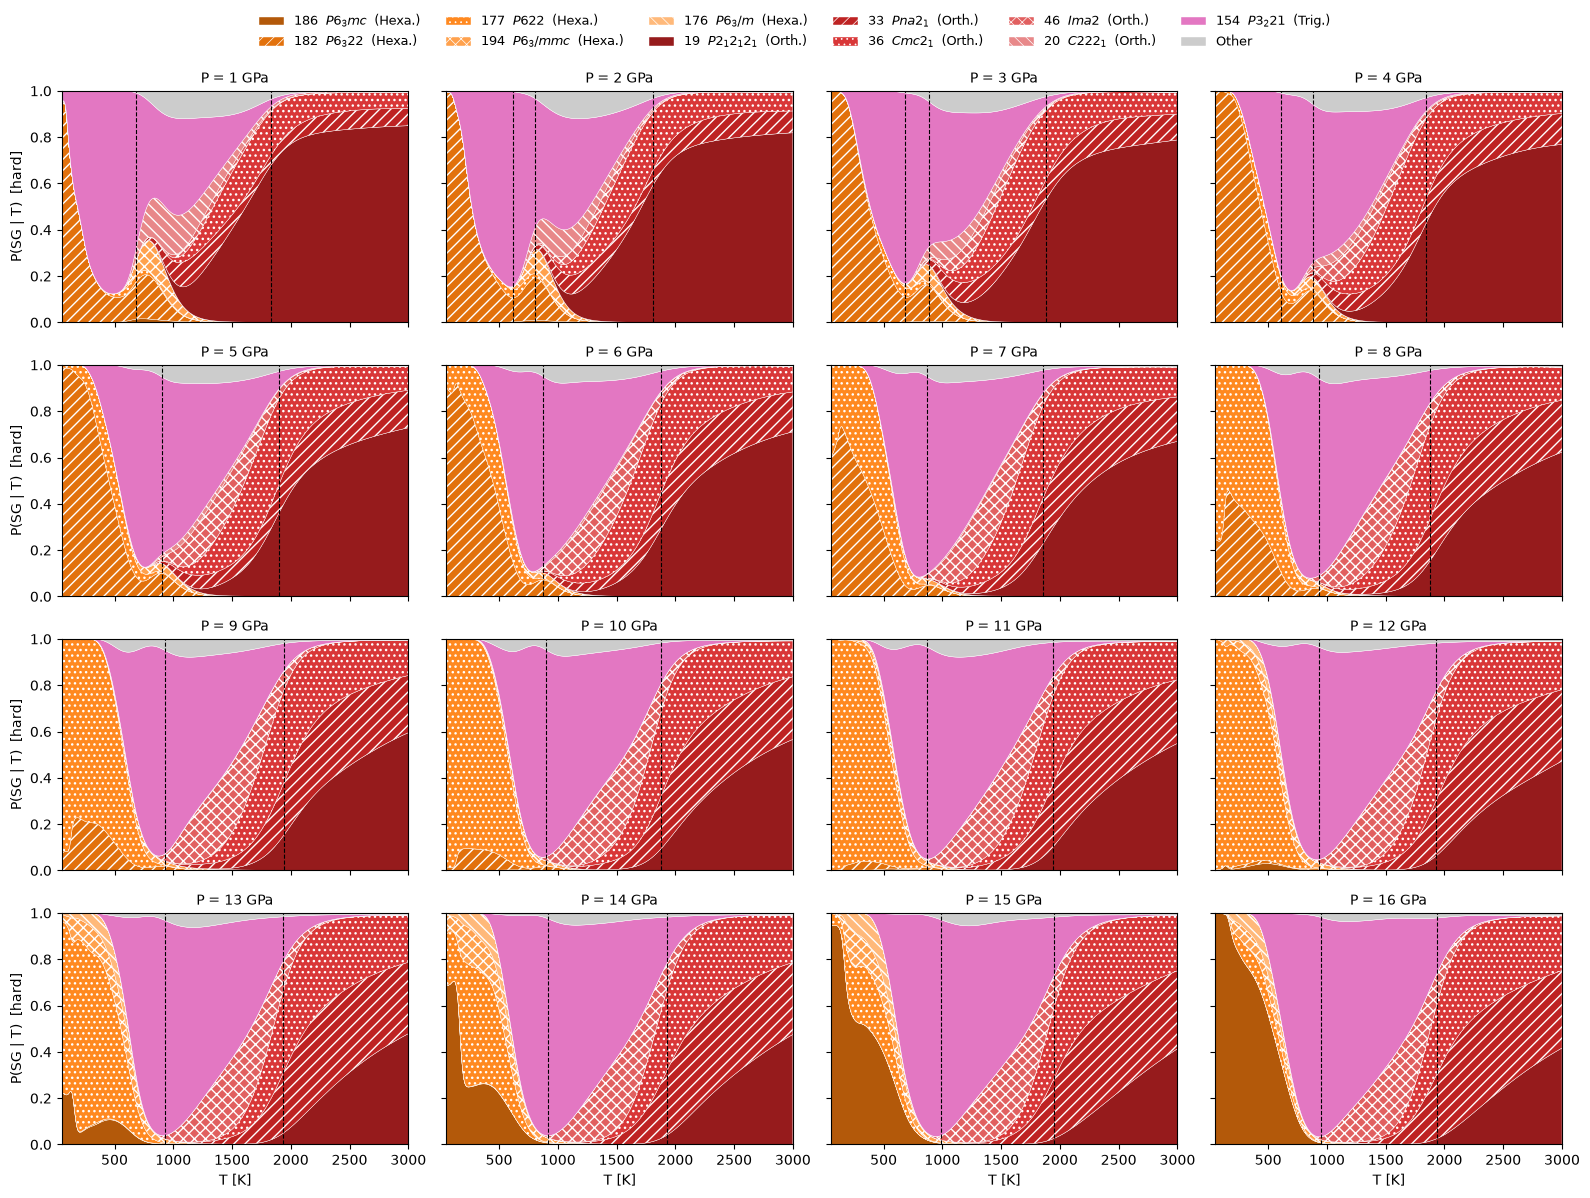

In [26]:
def sg_bands(idx):
    P = thermo[idx][SG_KEY]
    bands = [P[:, sg_col[s]] for s in shown_sg]
    bands.append(1.0 - np.sum(bands, axis=0).clip(max=1.0))
    return bands


styles = [SG_STYLE[s] for s in shown_sg] + [OTHER_STYLE]
labels = [sg_label(s) for s in shown_sg] + ["Other"]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharex=True, sharey=True)
for ax, idx, P in zip(axes.flat, replica_indices, pressures_gpa):
    polys = ax.stackplot(
        T_FINE, sg_bands(idx), colors=[st["color"] for st in styles], labels=labels,
        edgecolor="white", linewidth=0.3,
    )
    for poly, st in zip(polys, styles):
        poly.set_hatch(st["hatch"])
    for T_peak in cp_peaks[idx]:
        ax.axvline(T_peak, color="black", ls="--", lw=0.8)
    ax.set_title(f"P = {P:g} GPa", fontsize=10)
    ax.set_xlim(T_FINE[0], T_FINE[-1])
    ax.set_ylim(0, 1)
for ax in axes.flat[len(replica_indices):]:
    ax.set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("T [K]")
for ax in axes[:, 0]:
    ax.set_ylabel(f"P(SG | T)  [{LABEL_MODE}]")
plt.rcParams["hatch.linewidth"] = 0.5
handles, _ = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.0), fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.955))
fig.savefig(EVAL_DIR / f"spacegroup_vs_T_{LABEL_MODE}.png", dpi=200, bbox_inches="tight")
plt.show()

### (P, T) map of the dominant spacegroup

Same construction as the family map: color of the most probable SG (among all of them, not
only the shown ones -- a cell whose winner is outside `shown_sg` is drawn gray), opacity =
its probability.

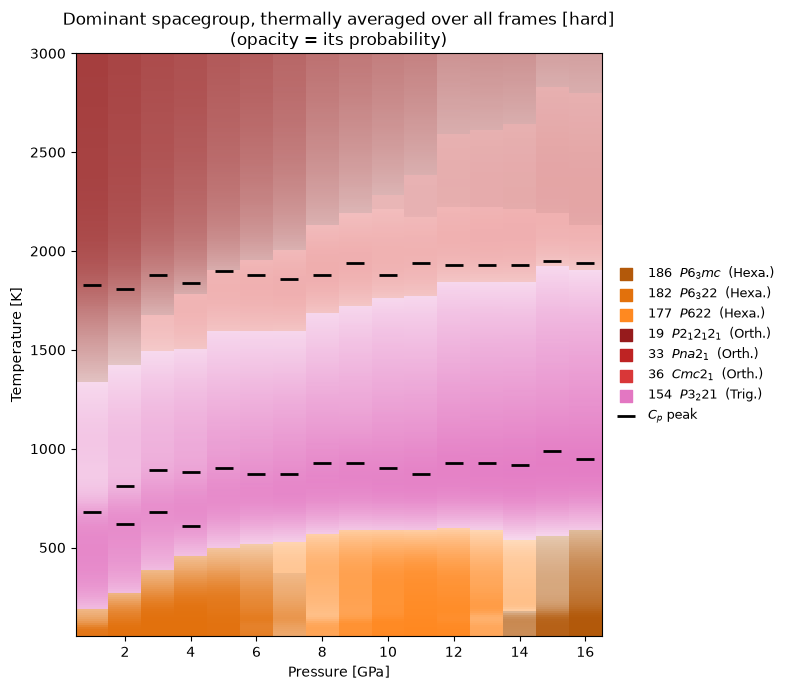

In [27]:
P_sg_mat = np.stack([thermo[idx][SG_KEY] for idx in replica_indices], axis=1)  # (n_T, n_P, n_sg)
dominant_sg = np.array(all_sg)[P_sg_mat.argmax(axis=-1)]
rgba = np.array(
    [[mcolors.to_rgba(SG_STYLE.get(s, OTHER_STYLE)["color"]) for s in row] for row in dominant_sg]
)
rgba[..., 3] = np.clip(P_sg_mat.max(axis=-1), 0.0, 1.0)

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(
    rgba, origin="lower", aspect="auto", interpolation="nearest",
    extent=(pressures_gpa[0] - dP / 2, pressures_gpa[-1] + dP / 2, T_FINE[0], T_FINE[-1]),
)
for idx, P in zip(replica_indices, pressures_gpa):
    ax.scatter([P] * len(cp_peaks[idx]), cp_peaks[idx], color="black", marker="_", s=150, lw=2)
for s in [s for s in shown_sg if s in set(dominant_sg.ravel())]:
    ax.scatter([], [], color=SG_STYLE[s]["color"], marker="s", s=80, label=sg_label(s))
if not set(dominant_sg.ravel()) <= set(shown_sg):
    ax.scatter([], [], color=OTHER_STYLE["color"], marker="s", s=80, label="Other")
ax.scatter([], [], color="black", marker="_", s=150, lw=2, label=r"$C_p$ peak")
ax.set_xlabel("Pressure [GPa]")
ax.set_ylabel("Temperature [K]")
ax.set_title(f"Dominant spacegroup, thermally averaged over all frames [{LABEL_MODE}]\n(opacity = its probability)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(EVAL_DIR / f"phase_map_spacegroup_{LABEL_MODE}.png", dpi=200, bbox_inches="tight")
plt.show()

### First observations (spacegroups)

- **Low T, Hexagonal**: the dominant SG changes with pressure -- $P6_322$ (182) at 1-7 GPa,
  $P622$ (177) at 8-13 GPa, $P6_3mc$ (186) at 14-16 GPa (at the lowest T). hcp's own $P6_3/mmc$ (194) never
  exceeds 16%. 182 and 186 are subgroups of 194 (hcp), while 177 is a subgroup of $P6/mmm$
  (191, the omega-Ti structure). A plausible reading, still to be checked: the classifier
  sees the right parent structure but, with thermal noise, answers a lower-symmetry
  (chiral/polar) subgroup of it instead of the centrosymmetric parent. Direct test: spglib
  with a loose tolerance on the low-T frames.
- **Trigonal is a single SG**: all of it is $P3_221$ (154), not a generic "trigonal" mixture.
- **Orthorhombic splits in two regimes.** Between the ~900 K and ~1900 K $C_p$ peaks the
  weight goes to $Ima2$ (46), $C222_1$ (20, low P only) and $Cmc2_1$ (36): body-centered or
  C-centered groups, compatible with a thermally distorted bcc (46 is a subgroup of
  $Imma \subset Im\bar{3}m$; 36 is a subgroup of $Cmcm$, the bcc <-> hcp Burgers-path
  intermediate). This supports the beta-Ti hypothesis without proving it. Above melting,
  $P2_12_12_1$ (19, the lowest-symmetry orthorhombic group, screw axes only) and $Pna2_1$
  (33) take over: the classifier's natural answer for a structure with no symmetry at all.